# IoT in Agricoltura

## Obiettivo
Classificare dati IoT da uno scenario Agriculture

## Dataset
- Utilizzeremo il dataset "IoT Agriculture 2024" da Kaggle
- Il dataset contiene misurazioni di sensori agricoli
- Target: predire l'attivazione del sistema di ventilazione (`Fan_actuator_ON`)

## Metriche di Valutazione
- Tempo di esecuzione per training e prediction
- Accuratezza della classificazione
- Matrice di confusione

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wisam1985/iot-agriculture-2024")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\miche\.cache\kagglehub\datasets\wisam1985\iot-agriculture-2024\versions\1


In [2]:
import pandas as pd
df = pd.read_csv(path + "/IoTProcessed_Data.csv")

In [3]:
df.describe()

,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
count,37922.000000,37922.000000,37922.000000,37922.000000,37922.000000,37922.000000,37922.000000,37922.000000,37922.000000,37922.000000,37922.000000,37922.000000
mean,18.760113,50.329308,79.401587,231.963610,234.123332,225.171879,0.689863,0.310137,0.762091,0.237909,0.774142,0.225858
std,7.143422,22.995645,36.824610,34.718121,31.452138,44.877635,0.462555,0.462555,0.425809,0.425809,0.418152,0.418152
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,49.000000,79.000000,185.000000,190.000000,160.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,17.000000,59.000000,100.000000,255.000000,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,25.000000,62.000000,100.000000,255.000000,255.000000,255.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,41.000000,100.000000,100.000000,255.000000,255.000000,259.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.head()

,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
0,2024-02-08 06:10:00,41,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
1,2024-02-08 06:15:00,41,59,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
2,2024-02-08 06:20:00,41,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
3,2024-02-08 06:05:00,40,60,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
4,2024-02-08 06:00:00,39,61,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0


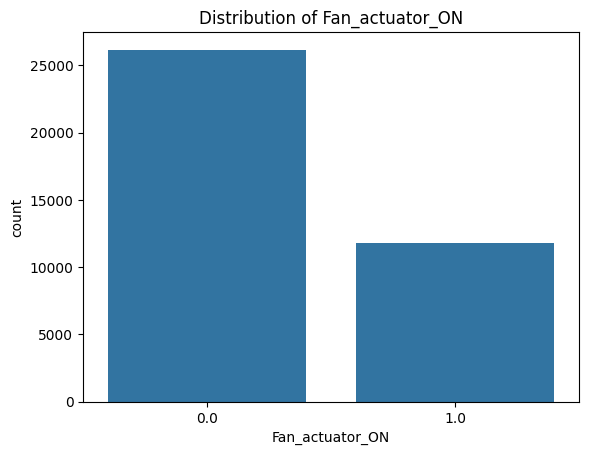

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Fan_actuator_ON', data=df)
plt.title('Distribution of Fan_actuator_ON')
plt.show()

In [6]:
df['date'] = pd.to_datetime(df['date'])   #trasformo la colonna data in oggetto datetime
#estraggo informazioni (ore e minuti) dal timestamp
df['hour'] = df['date'].dt.hour
df['minute'] = df['date'].dt.minute

In [7]:
df.head()

,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON,hour,minute
0,2024-02-08 06:10:00,41,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0,6.0,10.0
1,2024-02-08 06:15:00,41,59,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0,6.0,15.0
2,2024-02-08 06:20:00,41,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0,6.0,20.0
3,2024-02-08 06:05:00,40,60,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0,6.0,5.0
4,2024-02-08 06:00:00,39,61,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0,6.0,0.0


In [8]:
#Cancelliamo la colonna date
df.drop('date', axis=1, inplace=True)


In [9]:
# Cerchiamo i valori nulli
missing_values = df.isna().sum()
missing_values

tempreature                0
humidity                   0
water_level                0
N                          0
P                          0
K                          0
Fan_actuator_OFF           0
Fan_actuator_ON            0
Watering_plant_pump_OFF    0
Watering_plant_pump_ON     0
Water_pump_actuator_OFF    0
Water_pump_actuator_ON     0
hour                       2
minute                     2
dtype: int64

In [10]:
#Rimuoviamo le righe che contengono almeno un valore NaN
#altra soluzione: sostituisco i valori con la media (qui però mancano ore e minuti)
data_cleaned = df.dropna()

In [11]:
#Rinominiamo le caratteristiche e il target dopo la pulizia
X_cleaned = data_cleaned.drop(['Fan_actuator_ON', 'Fan_actuator_OFF'], axis=1)
y_cleaned = data_cleaned['Fan_actuator_ON']

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split train / test 
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(
    X_cleaned, y_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned
)

print("Train:", X_train_cleaned.shape)
print("Test:", X_test_cleaned.shape)

Train: (30336, 12)
Test: (7584, 12)


In [13]:
# Scaling the features
scaler_cleaned = StandardScaler()
X_train_scaled_cleaned = scaler_cleaned.fit_transform(X_train_cleaned)
X_test_scaled_cleaned = scaler_cleaned.transform(X_test_cleaned)

In [14]:
X_test_scaled_cleaned

array([[-0.52935145,  0.46395485,  0.55817056, ..., -0.53868349,
         0.04729469,  0.25045115],
       [-0.38908989,  0.68182083,  0.55817056, ..., -0.53868349,
        -0.09790637,  0.65655527],
       [-0.95013613,  0.76896723, -0.50387372, ...,  1.85637767,
         1.06370214,  0.3664809 ],
       ...,
       [-0.80987457, -1.88899773,  0.55817056, ..., -0.53868349,
         0.77330001,  0.3664809 ],
       [ 0.59274102, -1.97614412,  0.55817056, ..., -0.53868349,
        -1.54991702,  0.54052552],
       [-0.95013613, -1.84542453,  0.55817056, ..., -0.53868349,
         1.35410427, -1.25793559]], shape=(7584, 12))

### Risolviamo il dataset con KNN e con tutte le features

### Applichiamo PCA prima di risolvere il dataset

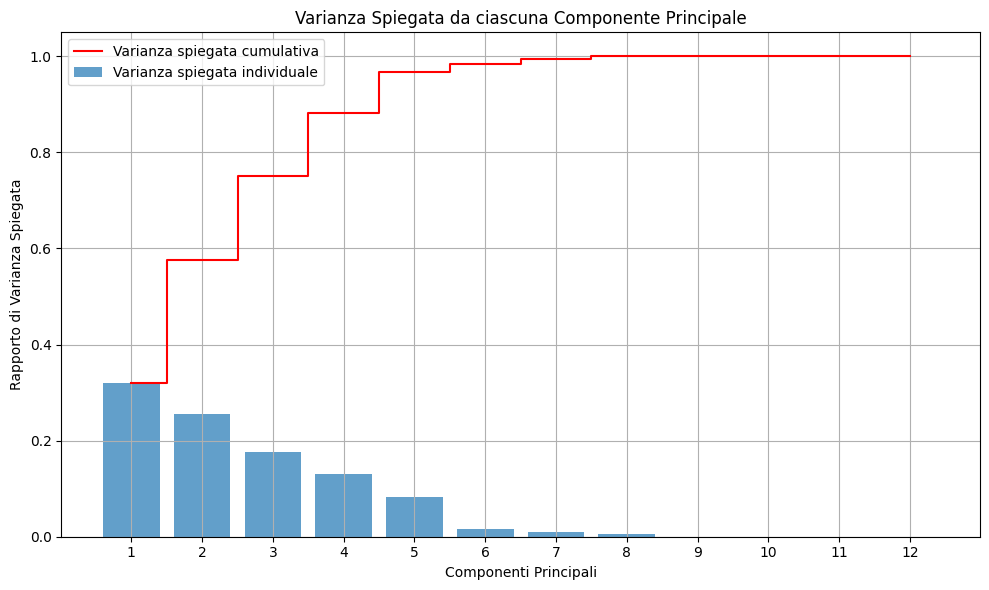

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA su tutti i dati di training scalati
pca_full = PCA()
pca_full.fit(X_train_scaled_cleaned)

n_components = X_train_scaled_cleaned.shape[1]

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_components + 1), pca_full.explained_variance_ratio_, alpha=0.7, align='center',
        label='Varianza spiegata individuale')
plt.step(range(1, n_components + 1), np.cumsum(pca_full.explained_variance_ratio_), where='mid',
         label='Varianza spiegata cumulativa', color='red')
plt.xlabel('Componenti Principali')
plt.ylabel('Rapporto di Varianza Spiegata')
plt.title('Varianza Spiegata da ciascuna Componente Principale')
plt.legend(loc='best')
plt.grid(True)
plt.xticks(range(1, n_components + 1))
plt.tight_layout()
plt.show()

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import time

# KNN sklearn SENZA PCA
start_time = time.time()
knn_sklearn = KNeighborsClassifier(n_neighbors=3)
knn_sklearn.fit(X_train_scaled_cleaned, y_train_cleaned)
y_pred_sklearn = knn_sklearn.predict(X_test_scaled_cleaned)
acc_sklearn = np.mean(y_pred_sklearn == y_test_cleaned)
time_sklearn = time.time() - start_time
print(f"KNN sklearn SENZA PCA: Accuratezza = {acc_sklearn:.4f}, Tempo = {time_sklearn:.4f} sec")

# KNN sklearn CON PCA (2 componenti)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled_cleaned)
X_test_pca = pca.transform(X_test_scaled_cleaned)

start_time = time.time()
knn_sklearn_pca = KNeighborsClassifier(n_neighbors=3)
knn_sklearn_pca.fit(X_train_pca, y_train_cleaned)
y_pred_sklearn_pca = knn_sklearn_pca.predict(X_test_pca)
acc_sklearn_pca = np.mean(y_pred_sklearn_pca == y_test_cleaned)
time_sklearn_pca = time.time() - start_time
print(f"KNN sklearn CON PCA: Accuratezza = {acc_sklearn_pca:.4f}, Tempo = {time_sklearn_pca:.4f} sec")

KNN sklearn SENZA PCA: Accuratezza = 0.9930, Tempo = 0.2361 sec
KNN sklearn CON PCA: Accuratezza = 0.9597, Tempo = 0.0265 sec


### Vediamo come varia l'accuratezza sulla base delle componenti PCA tenute

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import time
import pandas as pd

results = []
max_components = X_train_scaled_cleaned.shape[1]

for n_comp in range(1, max_components + 1):
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled_cleaned)
    X_test_pca = pca.transform(X_test_scaled_cleaned)
    
    start_time = time.time()
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_pca, y_train_cleaned)
    y_pred = knn.predict(X_test_pca)
    elapsed = time.time() - start_time
    acc = np.mean(y_pred == y_test_cleaned)
    results.append({
        "Componenti PCA": n_comp,
        "Accuratezza": acc,
        "Tempo (s)": elapsed
    })

df_results = pd.DataFrame(results)
print(df_results)

    Componenti PCA  Accuratezza  Tempo (s)
0                1     0.862605   0.019278
1                2     0.959652   0.027529
2                3     0.982331   0.034056
3                4     0.990374   0.037552
4                5     0.974552   0.059602
5                6     0.994594   0.080543
6                7     0.993539   0.091643
7                8     0.993143   0.100641
8                9     0.993012   0.111942
9               10     0.993012   0.119668
10              11     0.993012   0.137803
11              12     0.993012   0.134708


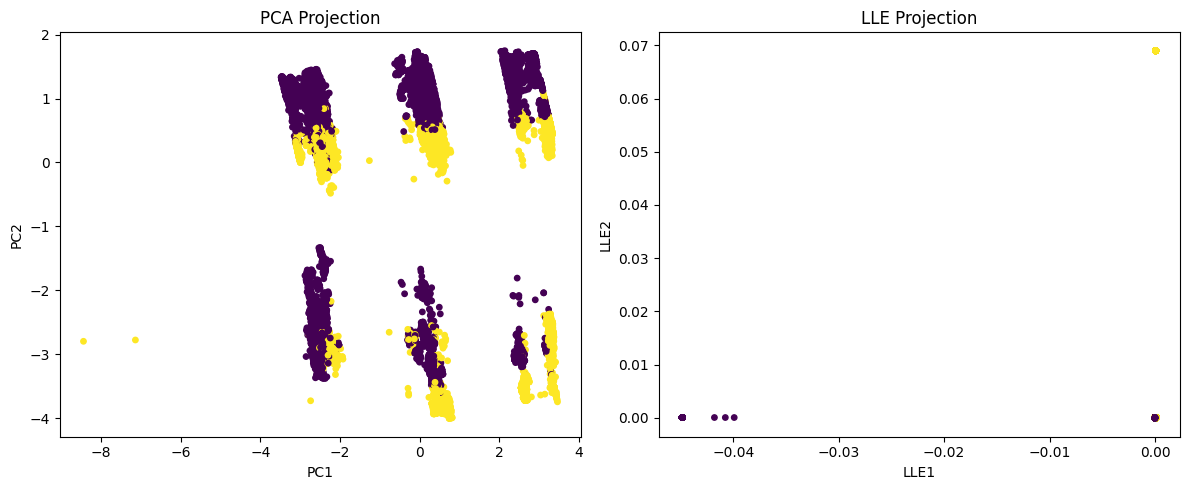

Original feature space shape: (30336, 12)
Both PCA and LLE are applied to the SAME scaled dataset.
The difference comes from the different geometric assumptions.


In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding
import matplotlib.pyplot as plt

# PCA projection
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled_cleaned)

# LLE projection
lle = LocallyLinearEmbedding(
    n_neighbors=12,
    n_components=2,
    method='standard'
)

X_lle_2d = lle.fit_transform(X_train_scaled_cleaned)

# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# PCA plot
ax[0].scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y_train_cleaned,
    cmap='viridis',
    s=15
)

ax[0].set_title("PCA Projection")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

# LLE plot
ax[1].scatter(
    X_lle_2d[:, 0],
    X_lle_2d[:, 1],
    c=y_train_cleaned,
    cmap='viridis',
    s=15
)

ax[1].set_title("LLE Projection")
ax[1].set_xlabel("LLE1")
ax[1].set_ylabel("LLE2")

plt.tight_layout()
plt.show()

print(f"Original feature space shape: {X_train_scaled_cleaned.shape}")
print("Both PCA and LLE are applied to the SAME scaled dataset.")
print("The difference comes from the different geometric assumptions.")

### Observation:

The LLE embedding is highly compressed around the origin.

This suggests that:

- local neighborhood relationships are very similar,
- the dataset may not contain a strong nonlinear manifold structure,
- or the chosen neighborhood size is not capturing meaningful local geometry.

Compared to LLE, PCA reveals a more interpretable global structure for this dataset.

# Possibile pipeline ML con PCA e LLE

## 1. Exploratory Data Analysis (EDA)

Prima di costruire il modello è utile comprendere la struttura del dataset.

Analisi tipiche:

- statistiche descrittive (`describe`)
- distribuzione delle feature
- valori mancanti (`NaN`)
- outlier
- Verifica bilanciamento delle classi

---

## 2. Train/Test Split

La separazione training/test deve avvenire prima delle trasformazioni che apprendono parametri dai dati.

Questo evita data leakage.

---

## 3. Feature cleaning (training set)

Possibili operazioni:

- rimozione feature costanti,
- rimozione feature duplicate,
- gestione valori mancanti.

Anche se PCA riduce la ridondanza automaticamente, una pulizia minima può:

- migliorare stabilità numerica,
- ridurre costo computazionale.

---

## 4. Analisi delle relazioni tra feature e target

Le analisi successive vengono eseguite sul training set per evitare data leakage.

### Correlazione feature-feature

Serve a individuare:

- ridondanza,
- dipendenze lineari,
- gruppi di feature simili.

Se molte feature sono fortemente correlate, la PCA potrebbe comprimere bene il dataset.

---

### Correlazione feature-target

Misura relazioni lineari tra feature e target.

Utile per:

- capire quali feature sono informative,
- valutare la presenza di dipendenze lineari.

---

### Mutual Information (MI)

La Mutual Information misura dipendenze anche non lineari.

Confrontare correlazione e MI può aiutare a capire la natura del problema:

| Situazione | Interpretazione |
|---|---|
| alta correlazione + alta MI | relazione prevalentemente lineare |
| bassa correlazione + alta MI | possibile struttura non lineare |
| bassa correlazione + bassa MI | feature poco utile |

Questa fase aiuta a identificare:

- feature ridondanti,
- relazioni lineari,
- possibili relazioni non lineari,
- feature poco informative,
- problemi nei dati.

---

## 5. Scaling / Standardizzazione

Lo scaling viene appreso solo sul training set.

Lo scaling è particolarmente importante per:

- PCA,
- LLE,
- KNN,
- algoritmi basati su distanza.

---

## 6. PCA come feature reduction operativa

La PCA cerca direzioni lineari globali che massimizzano la varianza.

PCA è utile per:

- ridurre dimensionalità,
- comprimere ridondanza lineare,
- ridurre rumore,
- accelerare il training.

---

### Analisi utili dopo PCA

- explained variance ratio
- cumulative explained variance
- numero di componenti necessarie
- confronto prestazioni con/senza PCA

---

## 6. LLE come manifold exploration

LLE non deve essere interpretato come una "PCA non lineare".

Obiettivo di LLE:

> preservare la geometria locale del dataset.

LLE è utile per:

- esplorare struttura non lineare,
- visualizzare manifold,
- osservare separazione locale delle classi.

LLE viene utilizzato solo a scopo esplorativo e non come trasformazione operativa della pipeline ML (usa lo stesso dataset in ingresso a PCA, non quello trasformato).

---

### Informazioni utili da osservare con LLE

- cluster naturali,
- separazione delle classi,
- struttura geometrica locale,
- eventuali manifold non lineari.

---

## 8. Interpretazione di PCA e LLE

Il confronto tra PCA e LLE può aiutare a comprendere meglio la struttura del dataset.

| Situazione | Possibile interpretazione |
|---|---|
| PCA e LLE mostrano separazione simile | struttura relativamente lineare |
| PCA separa bene le classi | modelli lineari potrebbero essere sufficienti |
| LLE mostra separazione migliore di PCA | possibile struttura non lineare locale |
| LLE evidenzia cluster/manifold curvi | possibile geometria non lineare del dataset |
| forte overlap sia in PCA che in LLE | problema probabilmente difficile o classi poco separabili |

---

## 9. Scelta del modello
| Osservazione | Possibili modelli adatti |
|---|---|
| struttura lineare | Logistic Regression, Linear SVM |
| struttura moderatamente non lineare | Kernel SVM |
| struttura locale/manifold complessa | ensemble, neural networks |

Le analisi precedenti possono aiutare nella scelta del modello.

| Osservazione | Possibile implicazione |
|---|---|
| forte correlazione lineare | modelli lineari efficaci |
| alta MI ma bassa correlazione | possibile struttura non lineare |
| buona separazione con PCA | struttura globale semplice |
| buona separazione con LLE | possibile manifold non lineare |

---

## 10. Training e valutazione

Fase finale:

- training del modello,
- validazione,
- valutazione sul test set.

Metriche comuni:

- accuracy
- precision
- recall
- F1-score
- confusion matrix